In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import pypsa

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [2]:
necp = pd.read_csv(
    Path.cwd().parent / 'data' / 'Ember_NECP_data_2024.csv'
).set_index(['SHORT_COUNTRY_CODE', 'FUEL_CODE', 'YEAR', 'KPI'])

In [3]:
tyndp_2030 = pd.read_csv(
    Path.cwd().parent / 'resources' / 'tyndp_capacities_2030.csv', index_col=0, header=[0, 1]
).mul(1e-3)
tyndp_2035 = pd.read_csv(
    Path.cwd().parent / 'resources' / 'tyndp_capacities_2035.csv', index_col=0, header=[0, 1]
).mul(1e-3)

In [4]:
countries = [
    'DE', 'FR', 'GB', 'IT', 'ES', 'PL', 'SE', 'NO', 'NL', 'FI', 'RO', 'GR',
    'PT', 'CZ', 'BE', 'AT', 'BG', 'DK', 'HU', 'IE'# , 'HR', 'LT', 'LV', 'EE'
]

In [5]:
techs = ['onwind', 'offwind', 'solar', 'battery']

In [6]:
idx = pd.IndexSlice

In [7]:
n_2030 = pypsa.Network(Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT+fast_endo.nc')
n_2035 = pypsa.Network(Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_endo.nc')

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT+fast_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT+fast_endo.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [208]:
def get_model_capacity(n, cc, carrier):
    covered = ['solar', 'onwind', 'offwind', 'battery', 'industry gas', 'gas boiler']
    assert carrier in covered, f"Carrier {carrier} not in covered,\ncovered: {covered}"

    if isinstance(n, str):
        n = pypsa.Network(n)

    if carrier == 'solar':
        gens = n.generators.loc[n.generators.carrier.isin(['solar', 'solar-hsat']) & n.generators.index.str.startswith(cc)]
        return gens['p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'onwind':
        gens = n.generators.loc[n.generators.carrier.isin(['onwind']) & n.generators.index.str.startswith(cc)]
        return gens['p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'offwind':
        gens = n.generators.loc[n.generators.carrier.isin(['offwind-ac', 'offwind-dc', 'offwind-float']) & n.generators.index.str.startswith(cc)]
        return gens['p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'battery':
        links = n.links.loc[n.links.carrier.isin(['battery discharger', 'home battery discharger']) & n.links.index.str.startswith(cc)]
        return links['p_nom_opt'].sum() / 1e3 # to GW

    elif carrier == 'industry gas':
        cs = ['heat100-200 industry gas', 'heat200-500 industry gas', 'heat>500 industry gas']
        l = n.links.index[n.links.carrier.isin(cs) & n.links.index.str.startswith(cc)]
        
        return n.links_t.p0.loc[:, l].mul(n.snapshot_weightings.objective, axis=0).sum().sum() / 1e6

    elif carrier == 'gas boiler':
        l = n.links.index[n.links.carrier.str.contains('gas boiler') & n.links.index.str.startswith(cc)]
        return n.links_t.p0.loc[:, l].sum(axis=1).mul(n.snapshot_weightings['generators']).sum() / 1e6

get_model_capacity(n_2030, 'DE', 'solar')

213.00452007291324

In [209]:
num_households = { # in millions
    'DE': 41.3,
    'FR': 31.7,
    'GB': 28.6,
    'IT': 26.1,
    'ES': 19.4,
    'PL': 14.7,
    'SE': 4.9,
    'NO': 2.65,
    'NL': 8.4,
    'FI': 2.7,
    'RO': 7.1,
    'GR': 4.6,
    'PT': 4.1,
    'CZ': 4.6,
    'BE': 5.2,
    'AT': 4.2,
    'BG': 2.9,
    'DK': 2.9,
    'HU': 4.4,
    'IE': 1.8,
}

# we will assume that share of heat pumps supply times num households is the total number of heat pumps

In [210]:
def get_hp_shares(n, countries):
    heating_demands = ['rural heat', 'urban decentral heat', 'urban central heat']
    
    ss = n.statistics.energy_balance(groupby=['carrier', 'bus_carrier', 'bus'])
    ss = ss.loc[ss > 0.]
    
    hp_shares = pd.Series(np.nan, index=countries)
    
    for c in countries:
        sss = ss.loc[ss.index.get_level_values(3).str.startswith(c)]
        sss = sss.loc[sss.index.get_level_values(2).isin(heating_demands)]
        
        total_supply = sss.sum()
        hp_supply = sss.loc[sss.index.get_level_values(1).str.contains('heat pump')].sum()
        
        hp_share = hp_supply / total_supply
        hp_shares.loc[c] = hp_share
    
    return hp_shares

hp_shares_2030 = get_hp_shares(n_2030, countries)
hp_shares_2035 = get_hp_shares(n_2035, countries)

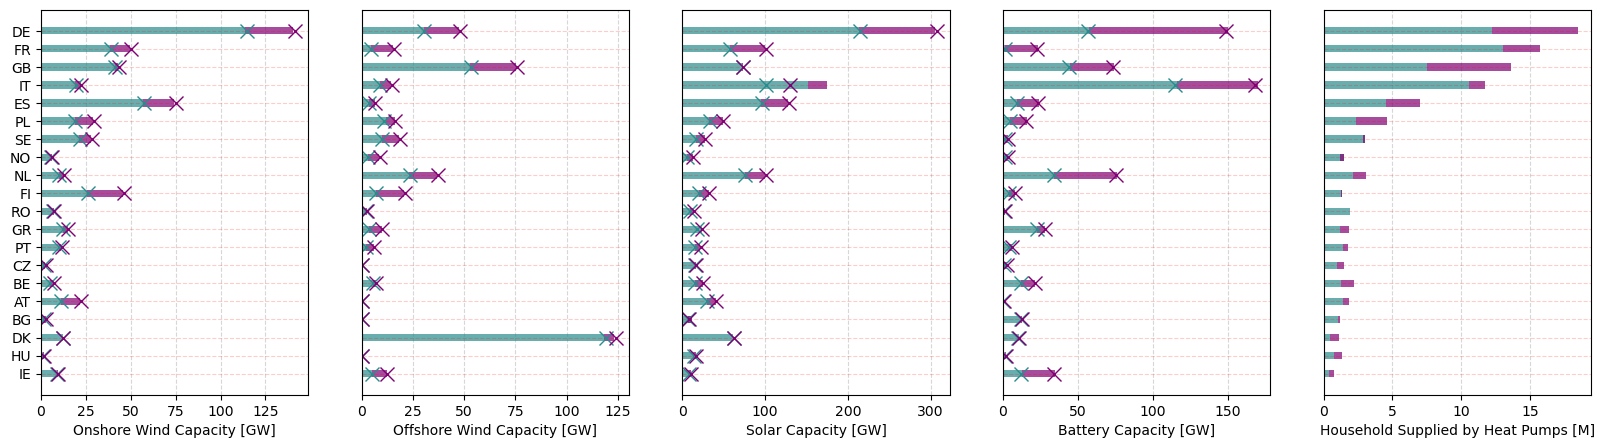

In [211]:
colors = {
    2030: '#298c8c',
    2035: '#800074'
}

fig, axs = plt.subplots(1, len(techs) + 1, figsize=(4*(len(techs) + 1), 5))

for ax, tech in zip(axs, techs):
    
    for i in range(len(countries)):
        ax.axhline(-i, color='r', linestyle='--', alpha=0.2, linewidth=0.8)
        c = countries[i]

        if tech == 'battery':
            value_2030 = tyndp_2030.loc[c, idx[['battery', 'home battery'], 'HIGH']].sum()
            value_2035 = tyndp_2035.loc[c, idx[['battery', 'home battery'], 'HIGH']].sum()
        else:
            value_2030 = tyndp_2030.loc[c, (tech, 'HIGH')]
            value_2035 = tyndp_2035.loc[c, (tech, 'HIGH')]

        ax.plot(value_2030, -i, marker='x', color=colors[2030], markersize=10)
        ax.plot(value_2035, -i, marker='x', color=colors[2035], markersize=10)

        model_2030 = get_model_capacity(n_2030, c, tech)
        model_2035 = get_model_capacity(n_2035, c, tech)

        ax.barh(-i, model_2030, height=0.4, color=colors[2030], alpha=0.7)
        ax.barh(-i, model_2035 - model_2030, left=model_2030, height=0.4, color=colors[2035], alpha=0.7)
    

ax = axs[-1]
for i in range(len(countries)):

    ax.axhline(-i, color='r', linestyle='--', alpha=0.2, linewidth=0.8)
    c = countries[i]

    # ax.plot(value_2030, -i, marker='x', color='blue', markersize=10)
    # ax.plot(value_2035, -i, marker='x', color='green', markersize=10)

    model_2030 = hp_shares_2030.loc[c] * num_households[c]
    model_2035 = hp_shares_2035.loc[c] * num_households[c]

    ax.barh(-i, model_2030, height=0.4, color=colors[2030], alpha=0.7)
    ax.barh(-i, model_2035 - model_2030, left=model_2030, height=0.4, color=colors[2035], alpha=0.7)


axs[0].set_yticks(range(-len(countries) + 1, 1))
axs[0].set_yticklabels(countries[::-1])

for ax in axs[1:]:
    ax.set_yticks([])

axs[0].set_xlabel('Onshore Wind Capacity [GW]')
axs[1].set_xlabel('Offshore Wind Capacity [GW]')
axs[2].set_xlabel('Solar Capacity [GW]')
axs[3].set_xlabel('Battery Capacity [GW]')
axs[4].set_xlabel('Household Supplied by Heat Pumps [M]')

for ax in axs:
    ax.grid(True, axis='x', alpha=0.5, linestyle='--')
    ax.set_axisbelow(True)

# plt.tight_layout()
plt.show()

In [184]:
gens = n_2035.generators.loc[n_2035.generators.carrier.str.contains('offwind')]
gens.loc[gens.index.str.startswith('DK'), ['p_nom_max', 'p_nom_min', 'p_nom_opt']]

,p_nom_max,p_nom_min,p_nom_opt
Generator,,,
DK0 0 0 offwind-ac,75052.648378,74302.121894,74302.122039
DK1 0 0 offwind-ac,49173.393733,48681.659796,48681.659933
DK0 0 0 offwind-dc,0.000000,0.000000,0.000000
DK1 0 0 offwind-dc,0.000000,0.000000,0.000000
DK0 0 0 offwind-float,0.000000,0.000000,0.000000
DK1 0 0 offwind-float,0.000000,0.000000,0.000000


In [216]:
necp.index.unique(3)

Index(['Electricity generation', 'Net electricity imports',
       'Installed capacity', 'GHG emissions', 'Final energy demand by sector',
       'Final energy demand by fuel'],
      dtype='object', name='KPI')

In [220]:
ss = necp.loc[idx[:,:,2020,'Installed capacity']]['VALUE'].dropna()

In [221]:
ss.index.unique(1)

Index(['TOTAL', 'SOLAR', 'WIND', 'BIO', 'HYDRO', 'OTHRENEW', 'COAL', 'GAS',
       'OTHFOSS', 'OTHCLEAN', 'STORAGE'],
      dtype='object', name='FUEL_CODE')

In [223]:
ss.loc[idx[:,'GAS']]

SHORT_COUNTRY_CODE
ES    31.89
ES    31.89
HU     4.10
IE     3.76
LV     1.12
NL    18.20
PL     2.69
Name: VALUE, dtype: float64

In [8]:
n = n_2030.copy()

In [10]:
b = n.links.index[n.links.carrier == 'biogas to gas']
b

Index(['AL0 0 biogas to gas', 'AT0 0 biogas to gas', 'BA0 0 biogas to gas',
       'BE0 0 biogas to gas', 'BG0 0 biogas to gas', 'CH0 0 biogas to gas',
       'CZ0 0 biogas to gas', 'DE0 0 biogas to gas', 'DE0 1 biogas to gas',
       'DE0 2 biogas to gas', 'DE0 3 biogas to gas', 'DE0 4 biogas to gas',
       'DE0 5 biogas to gas', 'DK0 0 biogas to gas', 'DK1 0 biogas to gas',
       'EE0 0 biogas to gas', 'ES0 0 biogas to gas', 'ES6 0 biogas to gas',
       'FI1 0 biogas to gas', 'FR0 0 biogas to gas', 'FR0 1 biogas to gas',
       'FR0 2 biogas to gas', 'FR0 3 biogas to gas', 'FR0 4 biogas to gas',
       'FR5 0 biogas to gas', 'GB2 0 biogas to gas', 'GB2 1 biogas to gas',
       'GB3 0 biogas to gas', 'GR0 0 biogas to gas', 'HR0 0 biogas to gas',
       'HU0 0 biogas to gas', 'IE3 0 biogas to gas', 'IT0 0 biogas to gas',
       'IT0 1 biogas to gas', 'IT4 0 biogas to gas', 'LT0 0 biogas to gas',
       'LU0 0 biogas to gas', 'LV0 0 biogas to gas', 'ME0 0 biogas to gas',
       'MK0 

In [12]:
n.links.loc[b, 'bus3'] == ''

Link
AL0 0 biogas to gas    True
AT0 0 biogas to gas    True
BA0 0 biogas to gas    True
BE0 0 biogas to gas    True
BG0 0 biogas to gas    True
CH0 0 biogas to gas    True
CZ0 0 biogas to gas    True
DE0 0 biogas to gas    True
DE0 1 biogas to gas    True
DE0 2 biogas to gas    True
DE0 3 biogas to gas    True
DE0 4 biogas to gas    True
DE0 5 biogas to gas    True
DK0 0 biogas to gas    True
DK1 0 biogas to gas    True
EE0 0 biogas to gas    True
ES0 0 biogas to gas    True
ES6 0 biogas to gas    True
FI1 0 biogas to gas    True
FR0 0 biogas to gas    True
FR0 1 biogas to gas    True
FR0 2 biogas to gas    True
FR0 3 biogas to gas    True
FR0 4 biogas to gas    True
FR5 0 biogas to gas    True
GB2 0 biogas to gas    True
GB2 1 biogas to gas    True
GB3 0 biogas to gas    True
GR0 0 biogas to gas    True
HR0 0 biogas to gas    True
HU0 0 biogas to gas    True
IE3 0 biogas to gas    True
IT0 0 biogas to gas    True
IT0 1 biogas to gas    True
IT4 0 biogas to gas    True
LT0 0 biogas to

In [16]:
import pypsa
from pathlib import Path

n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_free_0.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_free_0.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [17]:
solids = [
    'forest residues',
    'industry wood',
    'landscape care',
    ]

liquids = [
    'sewage sludge',
    'manure and slurry',
    'straw',
]

In [19]:
n.generators.loc[n.generators.carrier.isin(solids), 'p_nom'].sum() * 1e-6

991.916162320608

In [20]:
n.generators.loc[n.generators.carrier.isin(liquids), 'p_nom'].sum() * 1e-6

318.5976090479337

In [21]:
n.generators.carrier.unique()

array(['nuclear', 'offwind-ac', 'offwind-dc', 'solar', 'onwind',
       'offwind-float', 'solar-hsat', 'ror', 'gas', 'oil primary',
       'urban central heat vent', 'urban central solar thermal',
       'municipal solid waste', 'forest residues', 'industry wood',
       'landscape care', 'sewage sludge', 'manure and slurry', 'straw',
       'unsustainable biogas', 'unsustainable solid biomass',
       'unsustainable bioliquids', 'solid biomass', 'coal',
       'solar rooftop', 'rural heat vent', 'rural solar thermal',
       'urban decentral heat vent', 'urban decentral solar thermal',
       'co2-ets'], dtype=object)

In [26]:
n.generators.loc[n.generators.carrier == 'unsustainable biogas', ['p_nom', 'marginal_cost', 'bus']].head()

,p_nom,marginal_cost,bus
Generator,,,
AL0 0 biogas unsustainable,0.000000e+00,62.446031,AL0 0 biogas
AT0 0 biogas unsustainable,1.646958e+06,62.445416,AT0 0 biogas
BA0 0 biogas unsustainable,1.228128e+04,62.445286,BA0 0 biogas
BE0 0 biogas unsustainable,1.777969e+06,62.444559,BE0 0 biogas
BG0 0 biogas unsustainable,3.911050e+05,62.445537,BG0 0 biogas


In [28]:
n.generators.loc[n.generators.carrier == 'manure and slurry', ['p_nom', 'marginal_cost', 'bus']].head()

,p_nom,marginal_cost,bus
Generator,,,
AL0 0 biogas manure and slurry,2.568146e+05,19.409593,AL0 0 biogas
AT0 0 biogas manure and slurry,8.556562e+05,19.409913,AT0 0 biogas
BA0 0 biogas manure and slurry,2.296161e+05,19.409278,BA0 0 biogas
BE0 0 biogas manure and slurry,6.064971e+06,19.409253,BE0 0 biogas
BG0 0 biogas manure and slurry,7.789578e+05,19.409213,BG0 0 biogas


In [33]:
n.generators.loc[n.generators.carrier == 'gas', 'marginal_cost']

Generator
AT0 0 gas    24.578242
BE0 0 gas    24.577087
BG0 0 gas    24.578368
CZ0 0 gas    24.577392
DE0 0 gas    24.577055
DE0 1 gas    24.578102
DE0 2 gas    24.578627
DE0 3 gas    24.578720
DE0 4 gas    24.577207
DE0 5 gas    24.578326
DK0 0 gas    24.578420
DK1 0 gas    24.577589
ES0 0 gas    24.578943
FI1 0 gas    24.577557
FR0 0 gas    24.577140
FR0 1 gas    24.578039
FR0 2 gas    24.578389
FR0 3 gas    24.577489
FR0 4 gas    24.577677
GB2 0 gas    24.578127
GB2 1 gas    24.578773
GB3 0 gas    24.578495
GR0 0 gas    24.577419
HR0 0 gas    24.577504
HU0 0 gas    24.578048
IE3 0 gas    24.578538
IT0 0 gas    24.578238
IT0 1 gas    24.578003
LT0 0 gas    24.578194
LV0 0 gas    24.578512
NL0 0 gas    24.578074
NO1 0 gas    24.578796
PL0 0 gas    24.578894
PT0 0 gas    24.578831
RO0 0 gas    24.578509
RS0 0 gas    24.577493
SE1 0 gas    24.577771
SK0 0 gas    24.577560
Name: marginal_cost, dtype: float64